In [1]:
# Upload file from your system
from google.colab import files
uploaded = files.upload()

# Load dataset
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")

# Check data
print(df.head())

Saving Mall_Customers.csv to Mall_Customers.csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


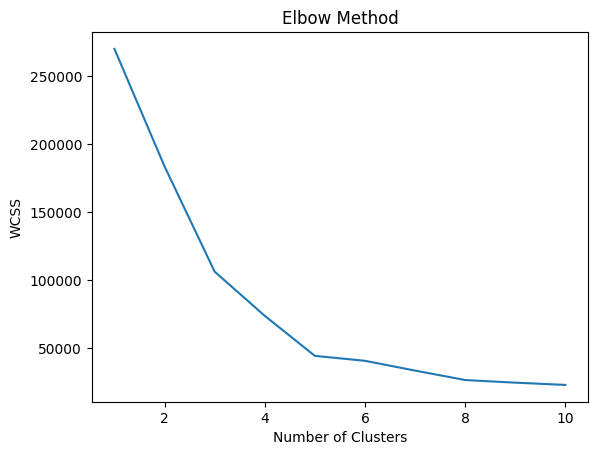

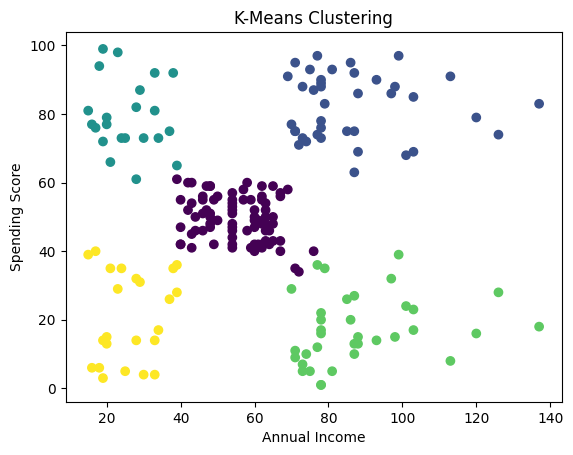

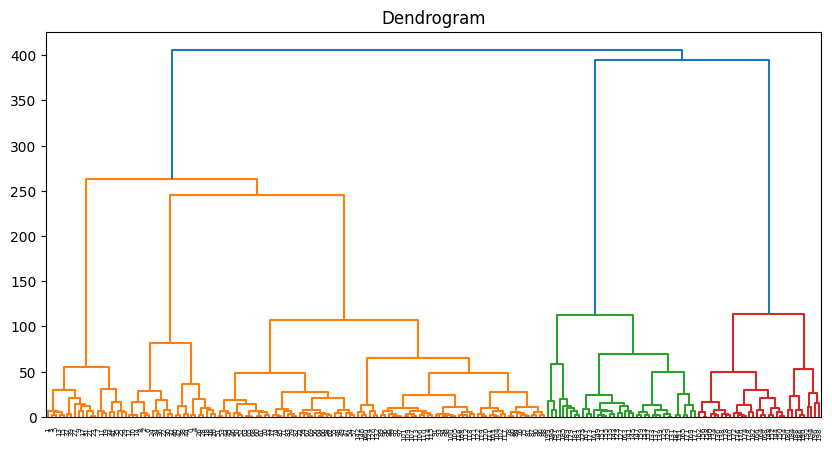

In [3]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 2: Load dataset
# The dataset was already loaded in the previous cell (GEo-bYOnvUHM).
# Using the existing 'df' DataFrame.
# url = "https://raw.githubusercontent.com/sharmaroshan/Mall-Customer-Segmentation-Dataset/master/Mall_Customers.csv"
# df = pd.read_csv(url)

# Step 3: Preprocessing
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Step 5: K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Plot clusters
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# Step 6: Hierarchical Clustering
Z = linkage(X, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()